In [50]:
import torch
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


In [51]:

# Load GPT-2
device = "mps"
model_name = "gpt2" # 12 layers, 12 heads, 768 hidden dim
# Load GPT-2 with 'eager' implementation to allow attention extraction
model = GPT2LMHeadModel.from_pretrained(
    "gpt2", 
    attn_implementation="eager"  # This is the crucial line
).to(device)

tokenizer = GPT2Tokenizer.from_pretrained(model_name)
# Map variables to your naming convention for convenience
enc = tokenizer

In [52]:
def test_prompt(model, start_text, encoder, test_sample, temperature=1.0):
    model.eval()
    
    # Tokenize input
    inputs = encoder(start_text, return_tensors="pt").to(device)
    idx = inputs['input_ids']
    
    with torch.no_grad():
        outputs = model(idx)
        logits = outputs.logits[0, -1, :] # [vocab_size]
    
    if temperature != 0:
        logits = logits / temperature

    probs = F.softmax(logits, dim=-1)
    p = probs.cpu()
    v = logits.cpu()

    sorted_values, original_indices = torch.sort(p, descending=True)
    
    # Handle the test token ID
    # GPT-2 tokenizer adds a space prefix if not careful
    test_token_ids = encoder.encode(test_sample, add_special_tokens=False)
    decoded_test_token = test_token_ids[0]

    print(f"Probability of '{test_sample}': {p[decoded_test_token]:.4f}")
    print("Token | Value (%)")
    print("---------------------")
    
    for i, (idx_val, prob_val) in enumerate(zip(original_indices, sorted_values)):
        decoded_token = encoder.decode([idx_val.item()])
        val_pct = prob_val.item() * 100
        
        # Show top 10 and the target token if found
        if i < 10 or idx_val == decoded_test_token:
            marker = "<- TARGET" if idx_val == decoded_test_token else ""
            print(f"Top {i:2d} | Logits: {v[idx_val].item():.3f}, Probs: {val_pct:6.3f}% | Token: '{decoded_token}' {marker}")

    return probs, logits

# Example Run
# Note: GPT-2 is sensitive to leading spaces. Use " O" vs "O"
_ = test_prompt(model, "AAB BBC CCD DDE EEF FFG GGH HHI IIJ JJK KKL LLM MMN NNO", enc, " OOP")

Probability of ' OOP': 0.4197
Token | Value (%)
---------------------
Top  0 | Logits: -117.371, Probs: 41.973% | Token: ' O' <- TARGET
Top  1 | Logits: -119.628, Probs:  4.392% | Token: ' NT' 
Top  2 | Logits: -119.706, Probs:  4.063% | Token: ' P' 
Top  3 | Logits: -119.735, Probs:  3.946% | Token: ' N' 
Top  4 | Logits: -119.961, Probs:  3.147% | Token: ' NZ' 
Top  5 | Logits: -120.034, Probs:  2.927% | Token: ' NO' 
Top  6 | Logits: -120.348, Probs:  2.138% | Token: ' OT' 
Top  7 | Logits: -120.666, Probs:  1.555% | Token: ' PS' 
Top  8 | Logits: -120.675, Probs:  1.542% | Token: ' NH' 
Top  9 | Logits: -120.688, Probs:  1.522% | Token: ' OB' 


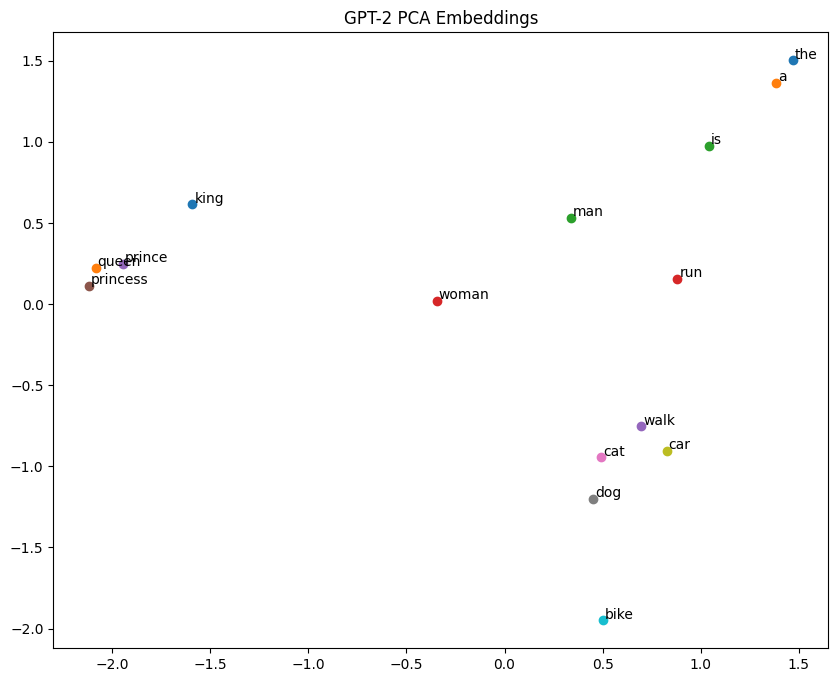

In [53]:
# Access GPT-2 embeddings via .transformer.wte
embeddings = model.transformer.wte.weight.detach().cpu().numpy()

words_to_track = ["king", "queen", "man", "woman", "prince", "princess", 
                  "cat", "dog", "car", "bike", "the", "a", "is", "run", "walk"]

# GPT-2 needs consistent spacing (most words in GPT-2 start with " ")
indices_to_track = [enc.encode(" " + word.strip(), add_special_tokens=False)[0] for word in words_to_track]
embeddings_subset = embeddings[indices_to_track]

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_subset)

plt.figure(figsize=(10, 8))
for i, word in enumerate(words_to_track):
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1])
    plt.text(embeddings_2d[i, 0] + 0.01, embeddings_2d[i, 1] + 0.01, word)
plt.title("GPT-2 PCA Embeddings")
plt.show()

In [54]:
def plot_attention_heads(qk_scores, token_ids, tokenizer, title='', figsize=(20, 15)):
    """
    qk_scores: Tensor of shape (batch, num_heads, seq_len, seq_len)
    token_ids: Tensor or List of token IDs matching the seq_len
    tokenizer: The encoder/tokenizer object used to decode IDs
    """
    # 1. Convert qk_scores to numpy safely
    if torch.is_tensor(qk_scores):
        qk_scores_np = qk_scores.detach().cpu().numpy()
    else:
        qk_scores_np = qk_scores
    
    batch, num_heads, seq_len, _ = qk_scores_np.shape

    # 2. Robust Token Decoding
    # This handles Tensors, Lists, and GPT-2's special space character 'Ġ'
    decodeds = []
    for i in token_ids:
        # Extract integer if it's a tensor
        val = i.item() if hasattr(i, 'item') else i
        # Decode and clean up GPT-2 space character
        tok_str = tokenizer.decode([val]).replace('Ġ', ' ')
        decodeds.append(tok_str)

    # 3. Validation
    if len(decodeds) != seq_len:
        print(f"Warning: Token list length ({len(decodeds)}) does not match seq_len ({seq_len})")
        decodeds = decodeds[:seq_len] 

    # 4. Grid Setup
    cols = 4
    rows = int(np.ceil(num_heads / cols))
    
    # Use squeeze=False to ensure 'axes' is always a 2D array
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    fig.suptitle(title, fontsize=20, fontweight='bold', y=1.02)
    
    # Distinct colors for each head
    base_colors = plt.cm.tab20(np.linspace(0, 1, num_heads))
    
    # 5. Plotting Loop
    for i in range(num_heads):
        ax = axes[i // cols, i % cols]
        
        # Custom colormap from White -> Head Color
        cmap = LinearSegmentedColormap.from_list(
            f'custom_cmap_{i}', 
            [(1, 1, 1), base_colors[i]], 
            N=256
        )

        # Draw Heatmap
        sns.heatmap(
            qk_scores_np[0, i, :, :], 
            cmap=cmap,
            ax=ax,
            cbar=True,
            xticklabels=decodeds,
            yticklabels=decodeds,
            vmin=0, 
            # Use max of this specific head for scaling, or 1.0 if all zeros
            vmax=max(0.01, np.max(qk_scores_np[0, i, :, :]))
        )
        
        ax.set_title(f'Head {i}', fontsize=14, fontweight='bold')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=10)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
        
    # Hide unused subplots if num_heads is not a multiple of 4
    for j in range(num_heads, rows * cols):
        axes[j // cols, j % cols].axis('off')
        
    plt.tight_layout()
    return fig


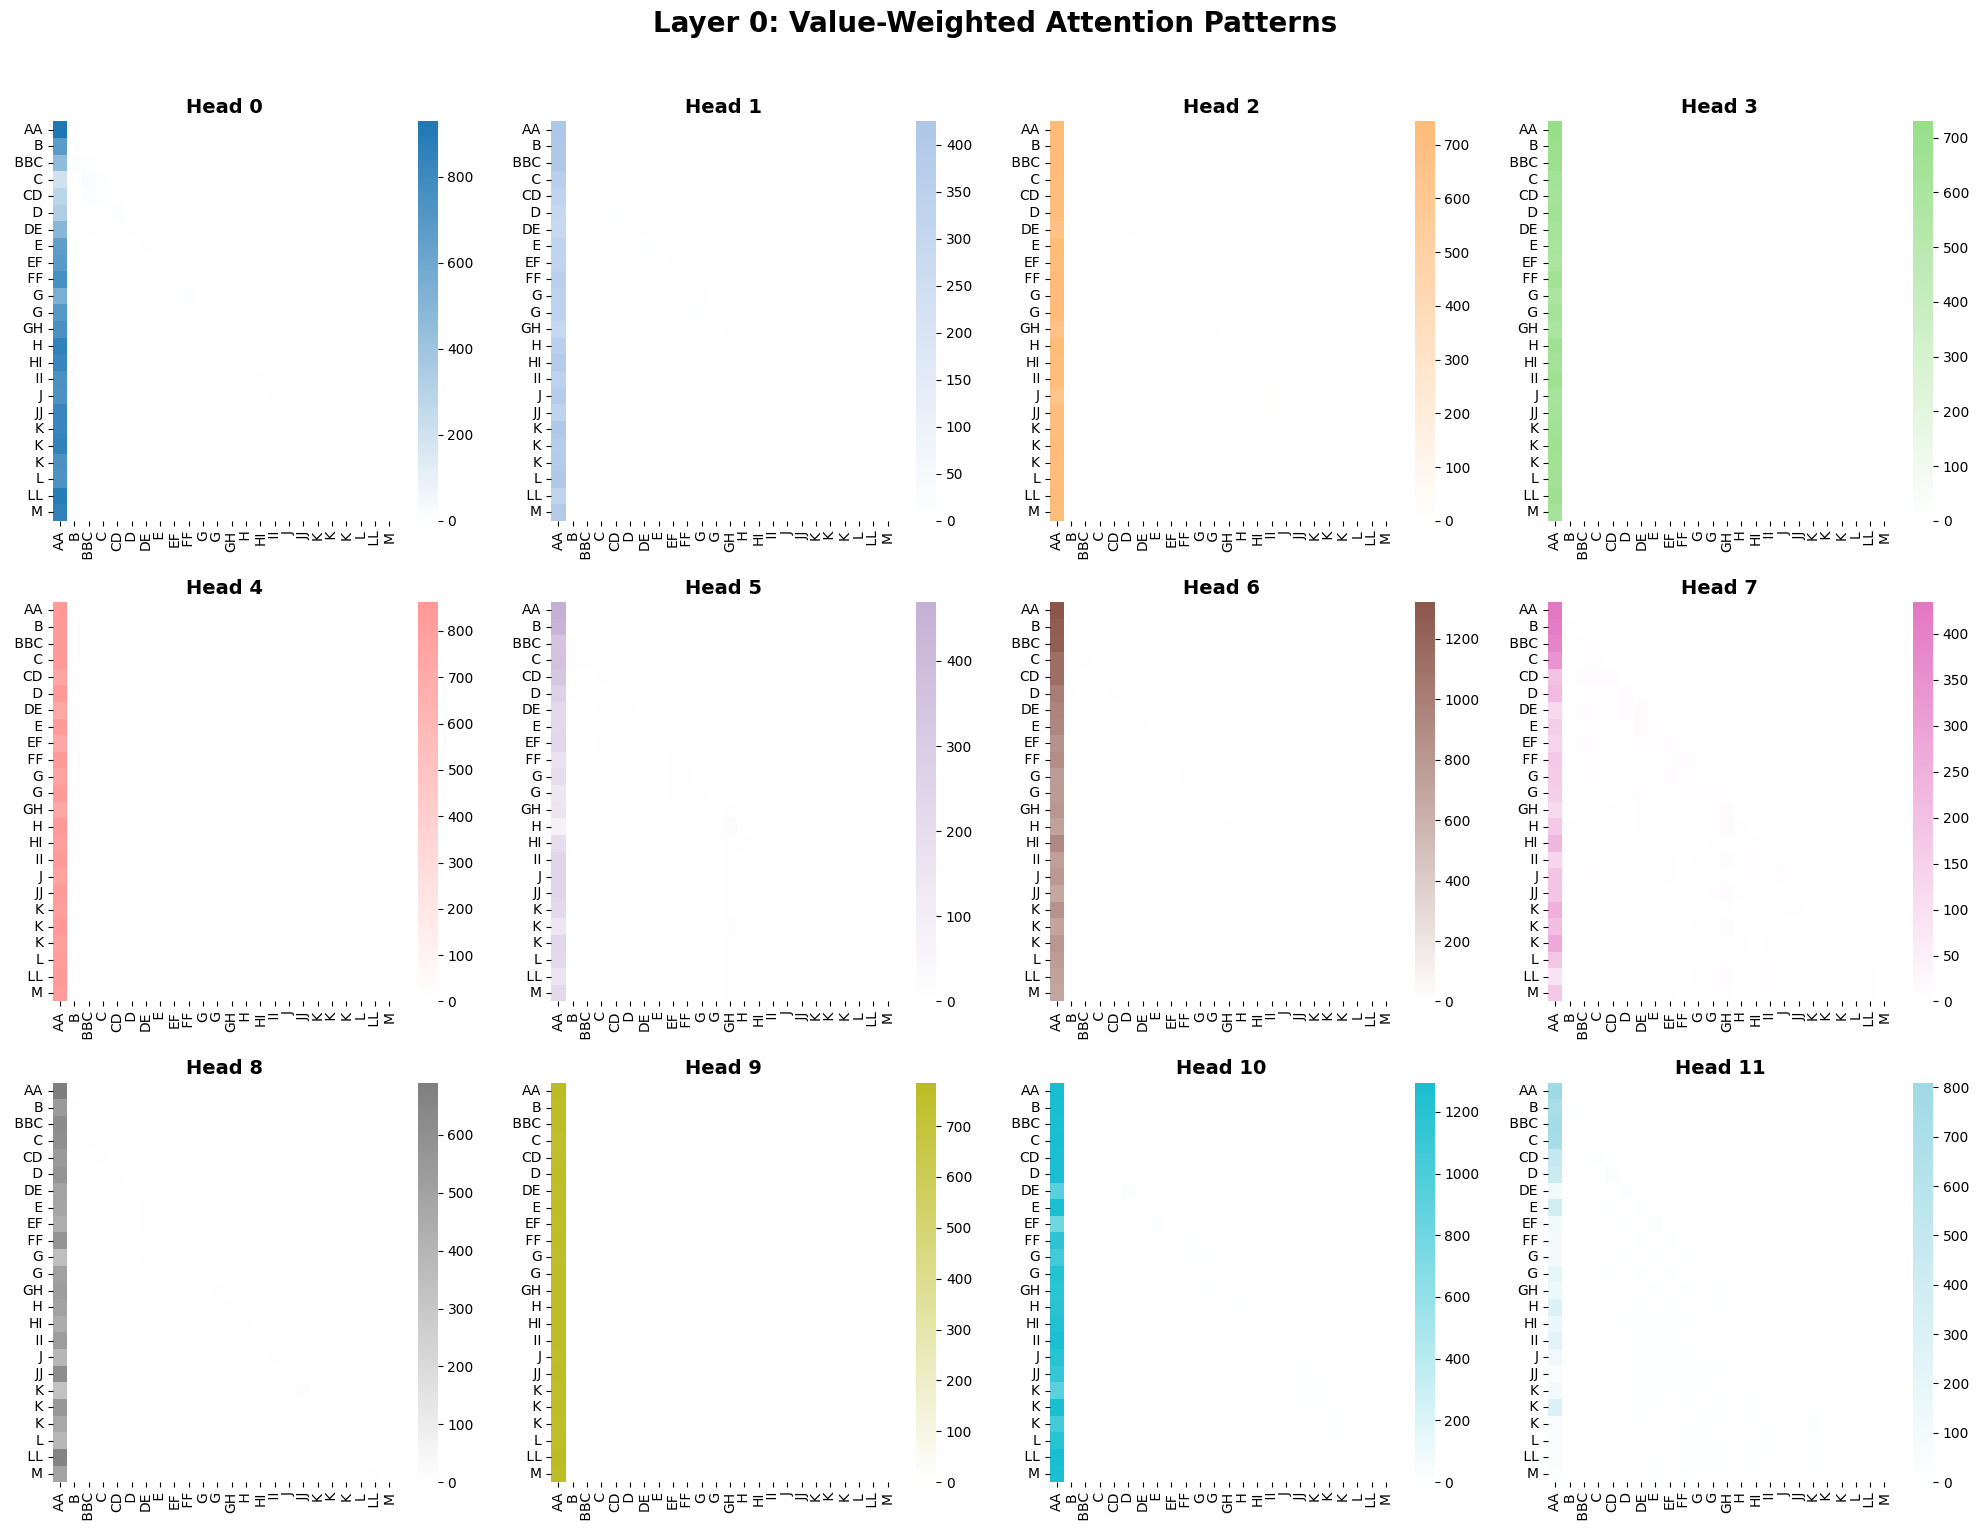

In [55]:
def get_weighted_attention(model, tokenizer, text, layer_idx, device="cuda"):
    model.eval()
    
    # 1. Handle Tokenization
    if hasattr(tokenizer, 'encode_plus'): # Hugging Face
        inputs = tokenizer(text, return_tensors="pt").to(device)
        token_ids = inputs['input_ids'][0]
    else: # Custom
        token_ids = torch.tensor(tokenizer.encode(text), device=device)
        inputs = {'input_ids': token_ids.unsqueeze(0)}

    # 2. Extract Data
    with torch.no_grad():
        # --- PATH A: Hugging Face Models ---
        if hasattr(model, 'transformer'):
            try:
                outputs = model(**inputs, output_attentions=True, output_hidden_states=True)
                
                if outputs.attentions is None:
                    raise ValueError(
                        "Model returned None for attentions. This happens if the model was loaded with "
                        "attn_implementation='sdpa'. Please reload your model using: "
                        "GPT2LMHeadModel.from_pretrained('gpt2', attn_implementation='eager')"
                    )
                
                patterns = outputs.attentions[layer_idx]
                hidden_in = outputs.hidden_states[layer_idx]
                
                # GPT-2 specific weight slicing
                attn_block = model.transformer.h[layer_idx].attn
                d_model = model.config.n_embd
                n_heads = model.config.n_head
                d_head = d_model // n_heads
                
                qkv = attn_block.c_attn(hidden_in) 
                v = qkv[..., 2*d_model:] 
                v = v.view(1, -1, n_heads, d_head).transpose(1, 2)

            except Exception as e:
                if "sdpa" in str(e).lower():
                    raise RuntimeError("SDPA detected. Reload model with attn_implementation='eager'") from e
                raise e

        # --- PATH B: Custom Transformer Class ---
        elif hasattr(model, 'num_layers'):
            # Use your custom 'return_all' logic
            logits, cache = model(inputs['input_ids'], return_all=True)
            patterns = cache['pattern'][layer_idx]
            v = cache['v'][layer_idx]
        
        else:
            raise TypeError("Unsupported model type.")

        # 3. Calculate Weighting
        v_norms = torch.norm(v, p=2, dim=-1).unsqueeze(-2)
        weighted_patterns = patterns * v_norms
        
    return weighted_patterns.cpu(), token_ids.cpu()
# --- RUN IT ---
# If using Hugging Face:
try:
    # Use 'tokenizer' for HF models, or 'enc' for your custom one
    weighted_attn, token_ids = get_weighted_attention(model, tokenizer, text, layer_idx=7, device=device)
    
    fig = plot_attention_heads(
        weighted_attn, 
        token_ids, 
        tokenizer, # Pass whichever encoder you are using
        title=f'Layer 0: Value-Weighted Attention Patterns'
    )
    plt.show()
except Exception as e:
    print(f"Analysis failed: {e}")

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Wedge
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def plot_anthropic_eigenvalues(heads_data):
    """
    Recreates the Anthropic paper's eigenvalue histogram with high visibility.
    """
    # 1. Setup figure
    num_bins = 10
    bins = np.linspace(-1.0, 1.0, num_bins + 1)
    bin_width = bins[1] - bins[0]
    
    # Calculate how many heads are in each bin to determine height
    bin_counts = np.zeros(num_bins)
    for d in heads_data:
        idx = np.digitize(d['score'], bins) - 1
        idx = max(0, min(idx, num_bins - 1))
        bin_counts[idx] += 1
    
    # DYNAMIC HEIGHT: If you have many heads (like GPT-2), the chart must be tall
    max_heads_in_bin = max(bin_counts)
    y_step = 1.6  # Vertical separation between circles
    fig_height = max(8, max_heads_in_bin * 0.9) 
    
    fig, ax = plt.subplots(figsize=(16, fig_height), facecolor='white')
    
    # Sort data for consistent stacking (Layer 0 at bottom, Layer 12 at top)
    sorted_heads = sorted(heads_data, key=lambda x: (x['layer'], x['head']))
    
    current_counts = np.zeros(num_bins)
    
    for head_info in sorted_heads:
        score = head_info['score']
        evals = head_info['evals']
        layer, head = head_info['layer'], head_info['head']
        
        # Find bin
        bin_idx = np.digitize(score, bins) - 1
        bin_idx = max(0, min(bin_idx, num_bins - 1))
        
        # Calculate Coordinates
        x_center = (bins[bin_idx] + bins[bin_idx+1]) / 2
        y_center = (current_counts[bin_idx] + 0.6) * y_step
        current_counts[bin_idx] += 1
        
        # --- Create Inset Axis (The mini-plot for each head) ---
        circle_size = bin_width * 0.85
        ax_ins = inset_axes(ax, width="100%", height="100%", 
                            bbox_to_anchor=(x_center - circle_size/2, y_center - circle_size/2, circle_size, circle_size), 
                            bbox_transform=ax.transData, loc='center', borderpad=0)
        
        ax_ins.set_axis_off()
        ax_ins.set_aspect('equal')
        ax_ins.set_xlim(-1.2, 1.2)
        ax_ins.set_ylim(-1.2, 1.2)
        
        # --- Draw Circle & Red Shading ---
        is_copying = score > 0.6
        border_color = '#D55E00' if is_copying else '#CCCCCC'
        bg_circle = Circle((0, 0), 1.0, facecolor='white', edgecolor=border_color, lw=1.5, zorder=1)
        ax_ins.add_patch(bg_circle)
        
        if is_copying:
            # Red wedge indicates "Copying" (Positive Real parts)
            wedge = Wedge((0, 0), 1.0, -90, 90, facecolor='#D55E00', alpha=0.2, zorder=2)
            ax_ins.add_patch(wedge)

        # --- Plot Eigenvalues ---
        max_mag = np.max(np.abs(evals)) if np.max(np.abs(evals)) > 0 else 1
        norm_evals = evals / max_mag
        
        pt_color = '#D55E00' if is_copying else '#4F8AC0'
        # Increased 's' (size) to 4 for better visibility
        ax_ins.scatter(norm_evals.real, norm_evals.imag, s=4, c=pt_color, alpha=0.8, zorder=3, edgecolors='none')
        
        # --- Place Label ---
        # Moving text slightly below the circle so it doesn't overlap the dots
        label_text = f"L{layer}.H{head}"
        ax_ins.text(0, -1.5, label_text, ha='center', va='top', 
                    fontsize=8, fontweight='bold', color='#333333')

    # --- Final Polish ---
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(0, (max_heads_in_bin + 1) * y_step)
    
    # X-axis label
    ax.set_xlabel(r"Copying Score: $\frac{\sum Re(\lambda)}{\sum |\lambda|}$", fontsize=16, labelpad=20)
    ax.set_ylabel("Number of Heads", fontsize=14)
    
    # Remove clutter
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.3)
    
    # Highlight the Trend (Where they "Mostly Exist")
    max_idx = np.argmax(bin_counts)
    trend_x = (bins[max_idx] + bins[max_idx+1]) / 2
    ax.annotate("Most heads cluster here\n(Copying Behavior)", 
                xy=(trend_x, bin_counts[max_idx] * y_step), 
                xytext=(trend_x - 0.4, (max_heads_in_bin + 0.5) * y_step),
                arrowprops=dict(facecolor='black', arrowstyle='->'),
                fontsize=12, fontweight='bold', color='#D55E00')

    plt.title("Eigenvalue Histograms (Labeled & Visible)", loc='left', fontsize=18, pad=30, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run it:
# data = get_eigenvalue_data(model)
# plot_anthropic_eigenvalues(data)

/var/folders/rf/h04h57cj31b591rd_k2072b00000gn/T/ipykernel_91611/4083335625.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


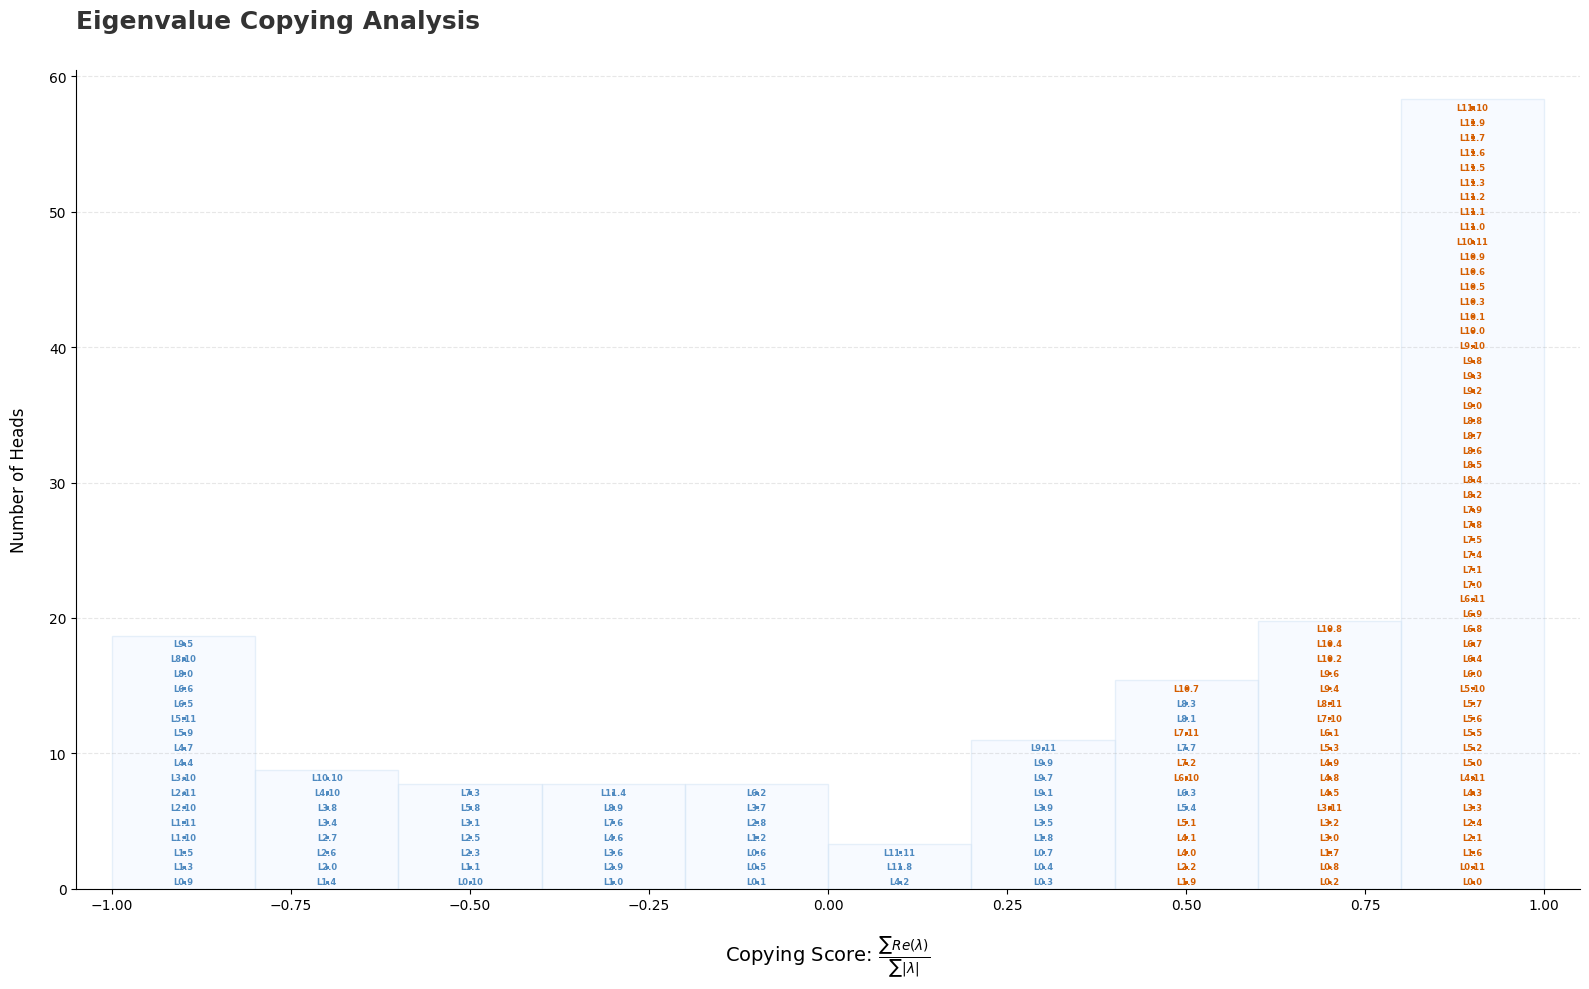

In [57]:
def get_eigenvalue_data_gpt2(model):
    device = next(model.parameters()).device
    heads_data = []
    
    # GPT-2 Config
    n_layers = model.config.n_layer
    n_heads = model.config.n_head
    d_model = model.config.n_embd
    d_head = d_model // n_heads

    W_E = model.transformer.wte.weight # [Vocab, d_model]
    W_U = model.lm_head.weight         # [Vocab, d_model]

    for l in range(n_layers):
        # GPT-2 c_attn weight is [d_model, 3*d_model]
        # It's stored as (Q, K, V)
        c_attn_weight = model.transformer.h[l].attn.c_attn.weight
        W_V_layer = c_attn_weight[:, 2*d_model:] # Get V part [d_model, d_model]
        
        # c_proj is the W_O matrix [d_model, d_model]
        W_O_layer = model.transformer.h[l].attn.c_proj.weight 

        for h in range(n_heads):
            start, end = h * d_head, (h + 1) * d_head
            
            # Slicing for this specific head
            # Transpose W_V because HF Conv1D is [in, out]
            W_V = W_V_layer[:, start:end].T # [d_head, d_model]
            W_O = W_O_layer[start:end, :]   # [d_head, d_model]
            
            with torch.no_grad():
                # Anthropic OV Circuit logic
                A = W_E @ W_V.T      # [Vocab, d_head]
                B = W_O @ W_U.T      # [d_head, Vocab]
                S = B @ A            # [d_head, d_head]
                
                evals = torch.linalg.eigvals(S.float().cpu()).numpy()
                score = np.real(evals).sum() / np.abs(evals).sum()
                
                heads_data.append({"layer": l, "head": h, "score": score, "evals": evals})
    return heads_data

# Use your existing plot function
data = get_eigenvalue_data_gpt2(model)
plot_anthropic_histogram_with_labels(data)

In [60]:
import pandas as pd
def analyze_gpt2_head(model, layer_idx, head_idx, source_token, topk=20):
    # 1. Get basic dimensions
    n_heads = model.config.n_head
    d_model = model.config.n_embd
    d_head = d_model // n_heads
    
    # 2. Extract Weights from the specific layer
    # GPT-2 stores Q,K,V fused in 'c_attn'
    attn_weights = model.transformer.h[layer_idx].attn.c_attn.weight # [d_model, 3*d_model]
    
    # Split into Q, K, V
    # Note: GPT-2 weights are stored as (d_model, 3*d_model) for Conv1D
    W_Q, W_K, W_V = torch.split(attn_weights, d_model, dim=-1)
    
    # Isolate the specific head
    # We slice based on head_idx * d_head
    start, end = head_idx * d_head, (head_idx + 1) * d_head
    w_q_h = W_Q[:, start:end] # [d_model, d_head]
    w_k_h = W_K[:, start:end] # [d_model, d_head]
    w_v_h = W_V[:, start:end] # [d_model, d_head]
    
    # Output projection weight
    W_O = model.transformer.h[layer_idx].attn.c_proj.weight # [d_model, d_model]
    w_o_h = W_O[start:end, :] # [d_head, d_model]
    
    # Unembedding and Embedding
    W_E = model.transformer.wte.weight # [vocab, d_model]
    W_U = model.lm_head.weight         # [vocab, d_model]
    
    # 3. Get Source Vector
    token_id = tokenizer.encode(source_token)[0]
    source_vec = W_E[token_id] # [d_model]
    
    # 4. QK Circuit: "Which tokens look at this source?"
    # Score = E_dest @ W_Q @ W_K.T @ E_src
    # Logic: We find the 'Query' version of all vocab and dot with our 'Key' source
    w_qk = w_q_h @ w_k_h.T
    qk_scores = W_E @ w_qk @ source_vec
    qk_vals, qk_idx = torch.topk(qk_scores, k=topk)
    qk_tokens = [tokenizer.decode([i]) for i in qk_idx]
    
    # 5. OV Circuit: "If we look at this source, what do we predict?"
    # Output = E_src @ W_V @ W_O @ W_U.T
    w_ov = w_v_h @ w_o_h
    ov_logits = source_vec @ w_ov @ W_U.T
    ov_vals, ov_idx = torch.topk(ov_logits, k=topk)
    ov_tokens = [tokenizer.decode([i]) for i in ov_idx]
    
    return qk_tokens, ov_tokens

# ==================== RUN ANALYSIS ====================
tokens_to_test = [" perfect", " large", " lambda", " if", " (", " January", " 1990"]
layer = 0  # Try Layer 0 first for "Previous Token" heads
head = 5   # Random head

results = []
for tok in tokens_to_test:
    qk, ov = analyze_gpt2_head(model, layer, head, tok)
    results.append({
        "Source": tok,
        "Destination (QK)": ", ".join(qk),
        "Output (OV)": ", ".join(ov)
    })

df = pd.DataFrame(results)
print(f"GPT-2 Layer {layer} Head {head} Analysis:")
display(df)

GPT-2 Layer 0 Head 5 Analysis:


,Source,Destination (QK),Output (OV)
0,perfect,"perfect, perfect, Perfect, Perfect, virtuou...","ャ, ILCS, ripple, odds, ippi, blo, parity,..."
1,large,"large, Large, huge, packed, huge, large, -, ...","ippi, proport, 905, honor, Rim, power, st..."
2,lambda,"galitarian, ğ, lambda, jriwal, uphem, lapt, p...","ILCS, hyde, netflix, PRESS, Pwr, squares, ..."
3,if,"if, ,, ., for, If, or, traged, of, unles...","and, the, "", you, destro, of, or, one,..."
4,(,"), (, ,, ., -, 's, of, /, :, "", ', (, and, ...","the, "", simple, good, be, those, more, ..."
5,January,"January, interstitial, January, ruary, soDeli...",""", and, heat, ever, issue, be, _________..."
6,1990,"soDeliveryDate, 1990, 1990, mares, ivals, nin...","��, ILCS, Devi, Beir, ウス, stir, vulner, ..."
